# **<span style="color:blue">Notebook 3 - Prof. Dr. Humberto Elias Lopes - Sintetizando Dados de Duas Variáveis</span>**
## <span style="color:blue"> 1) Tabulação Cruzada </span>

Nos dois primeiros notebooks, aprendemos como sintetizar o comportamento dos dados por meio de tabelas e gráficos para uma única variável. Neste Notebook, estenderemos essa possibilide para pares de variáveis, o que nos permite acessar a chamada análise bivariada de dados.

O primeiro recurso para isso é a chamada tabela cruzada. Nela, você aloca uma variável na coluna e outra, nas linhas, permitindo uma visualização conjunta dos dados. Como você pode observar, nesse tipo de tabela estamos nos restringindo à análise de duas variáveis. 

Em tese, você pode construir tabelas cruzadas com mais variáveis. Isso, porém, leva a um efeito indesejável: a tabela tende a se tornar difícil de analisar por causa do número de cruzamentos entre os dados. Portanto, o recomendável é que você escolha sempre a análise bivariada, mantendo apenas duas variáveis por tabela. Vejamos agora como utilizar esse recurso.

### **<span style="color:green">Na Prática 3.1</span>**:  Criando uma Tabela Cruzada. 

Para esta prática, vamos primeiramente usar o Python para criar um conjunto de dados fictício a partir do qual criaremos a tabela cruzada. O código é este:

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Semente pseudoaleatória fixa para reprodutibilidade em laboratório
np.random.seed(42)
n = 400

# 1. Atributos categóricos
canais = ["Loja Física", "Orgânico/SEO", "Mídia Paga", "Indicação"]
prob_canais = [0.25, 0.30, 0.30, 0.15]
canal = np.random.choice(canais, size=n, p=prob_canais)

# Fidelidade condicionada ao canal (Indicação e Loja Física aderem mais)
prob_adesao = {
    "Loja Física": 0.45,
    "Orgânico/SEO": 0.35,
    "Mídia Paga": 0.25,
    "Indicação": 0.70,
}
fidelidade = [
    "Sim" if np.random.rand() < prob_adesao[c] else "Não" for c in canal
]

segmentos = ["Varejo Geral", "Corporativo (PME)", "VIP"]
segmento = np.random.choice(segmentos, size=n, p=[0.55, 0.30, 0.15])

# 2. Atributos quantitativos com dependência linear e ruído controlado
investimento = np.random.gamma(shape=5.0, scale=120.0, size=n) + 150.0

# Coeficientes estruturais
beta_0 = 1200.0
beta_1 = 4.8
efeito_fidelidade = np.where(np.array(fidelidade) == "Sim", 900.0, 0.0)
ruido = np.random.normal(loc=0, scale=450.0, size=n)

receita = beta_0 + (beta_1 * investimento) + efeito_fidelidade + ruido

# Satisfação associada à receita gerada
satisfacao = []
for r in receita:
    if r < 3500:
        satisfacao.append(
            np.random.choice(
                ["Baixa", "Média", "Alta"], p=[0.50, 0.40, 0.10]
            )
        )
    elif r < 6000:
        satisfacao.append(
            np.random.choice(
                ["Baixa", "Média", "Alta"], p=[0.15, 0.60, 0.25]
            )
        )
    else:
        satisfacao.append(
            np.random.choice(
                ["Baixa", "Média", "Alta"], p=[0.05, 0.30, 0.65]
            )
        )

# Consolidação no DataFrame didático
df_varejo = pd.DataFrame(
    {
        "id_cliente": range(1001, 1001 + n),
        "canal_aquisicao": canal,
        "adesao_fidelidade": fidelidade,
        "segmento_cliente": segmento,
        "satisfacao_csat": satisfacao,
        "investimento_mkt_rs": np.round(investimento, 2),
        "receita_anual_rs": np.round(receita, 2),
    }
)

print(
    f"Base gerada com sucesso: {df_varejo.shape[0]} linhas e {df_varejo.shape[1]} colunas."
)

Base gerada com sucesso: 400 linhas e 7 colunas.


Agora que criamos o conjunto de dados, podemos estruturar a tabela cruzada. Como sempre, estamos usando as técnicas de storytelling de dados.

In [ ]:
# Construção da tabela cruzada: Frequências Absolutas com Totais Marginais
tab_cruzada_abs = pd.crosstab(
    df_varejo["canal_aquisicao"],
    df_varejo["adesao_fidelidade"],
    margins=True,
    margins_name="Total",
)

# Construção dos percentuais dentro de cada canal (frequência condicional por linha)
tab_cruzada_prop = (
    pd.crosstab(
        df_varejo["canal_aquisicao"],
        df_varejo["adesao_fidelidade"],
        normalize="index",
    )
    * 100
)

# Montagem de tabela executiva formatada
tab_executiva = pd.DataFrame(
    {
        "Clientes Não Aderentes": tab_cruzada_abs["Não"].astype(str)
        + " ("
        + tab_cruzada_prop["Não"].round(1).astype(str).str.replace(".", ",")
        + "%)",
        "Clientes Aderentes": tab_cruzada_abs["Sim"].astype(str)
        + " ("
        + tab_cruzada_prop["Sim"].round(1).astype(str).str.replace(".", ",")
        + "%)",
        "Total Geral": tab_cruzada_abs["Total"].astype(str),
    }
)

# Remoção da linha de total do cálculo de percentuais para manter consistência formal
tab_executiva.loc["Total", "Clientes Não Aderentes"] = (
    f"{tab_cruzada_abs.loc['Total', 'Não']} ({(tab_cruzada_abs.loc['Total', 'Não']/n)*100:.1f}%)".replace(
        ".", ","
    )
)
tab_executiva.loc["Total", "Clientes Aderentes"] = (
    f"{tab_cruzada_abs.loc['Total', 'Sim']} ({(tab_cruzada_abs.loc['Total', 'Sim']/n)*100:.1f}%)".replace(
        ".", ","
    )
)

# Estilização visual (Princípios de Cole Knaflic aplicados a tabelas)
estilo_tabela = (
    tab_executiva.style.set_caption(
        "<b>Tabela 1: Taxa de Adesão ao Programa Fidelidade por Canal de Aquisição</b><br>"
        "<span style='color: #555555; font-size: 9pt;'>Clientes oriundos de indicação apresentam o dobro da propensão média de adesão</span>"
    )
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("text-align", "left"),
                    ("font-family", "Arial, sans-serif"),
                    ("font-size", "11pt"),
                    ("margin-bottom", "10px"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("font-family", "Arial, sans-serif"),
                    ("font-size", "9.5pt"),
                    ("width", "100%"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("border-top", "1.5pt solid #111111"),
                    ("border-bottom", "1pt solid #111111"),
                    ("padding", "7px 14px"),
                    ("text-align", "center"),
                    ("color", "#222222"),
                    ("background-color", "#ffffff"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("border", "none"),
                    ("padding", "6px 14px"),
                    ("text-align", "center"),
                    ("color", "#444444"),
                ],
            },
            {
                "selector": "tbody tr:last-child",
                "props": [
                    ("border-top", "1pt solid #111111"),
                    ("border-bottom", "1.5pt solid #111111"),
                    ("font-weight", "bold"),
                    ("color", "#111111"),
                ],
            },
        ]
    )
    # Destaque seletivo da linha estratégica 'Indicação'
    .set_properties(
        subset=(
            ["Indicação"],
            ["Clientes Aderentes"],
        ),
        **{
            "background-color": "#e8f0fe",
            "color": "#1a73e8",
            "font-weight": "bold",
        },
    )
)

estilo_tabela

Observe que esta tabela permite que analisemos o perfil dos clientes em função do canal de aquisição dos produtos. Ou seja, estamos considerando duas variáveis simultaneamente, ao invés de apenas uma, como fizemos anteriormente.

## <span style="color:blue"> 2) Diagrama de Dispersão e Linha de Tendência </span>

O comportamento dos dados em duas variáveis também pode ser sintetizado por meio de gráficos, sendo o primeiro deles denominado diagrama de dispersão com linha de tendência. Abaixo, você tem um exemplo deste recurso.

In [ ]:
# Ajuste da reta de regressão linear simples (Mínimos Quadrados Ordinários)
x = df_varejo["investimento_mkt_rs"]
y = df_varejo["receita_anual_rs"]
inclinacao, intercepto = np.polyfit(x, y, 1)

# Coeficiente de determinação (R²)
correlacao = np.corrcoef(x, y)[0, 1]
r_quadrado = correlacao**2

# Configuração da figura
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=100)

# 1. Dados em segundo plano (cor neutra)
ax.scatter(
    x,
    y,
    color="#7f8c8d",
    alpha=0.45,
    s=45,
    edgecolors="none",
    label="Clientes regulares",
)

# 2. Destaque para clientes com investimento acima de R$ 1.200 e alta receita
destaque_mascara = (x > 1200) & (y > 7000)
ax.scatter(
    x[destaque_mascara],
    y[destaque_mascara],
    color="#1f77b4",
    alpha=0.9,
    s=65,
    edgecolors="#0b3c5d",
    linewidth=0.8,
    label="Clientes de Alto Impacto",
)

# 3. Linha de tendência analítica
x_reta = np.linspace(x.min(), x.max(), 100)
y_reta = intercepto + inclinacao * x_reta
ax.plot(
    x_reta,
    y_reta,
    color="#d95f02",
    linewidth=2.2,
    linestyle="-",
    zorder=4,
)

# 4. Título no formato Knaflic: Conclusão + Contexto de Apoio
plt.text(
    x=x.min() - 30,
    y=y.max() + 1100,
    s="Cada R$ 1,00 investido em relacionamento gera R$ 4,85 de retorno anual",
    fontsize=13,
    fontweight="bold",
    color="#111111",
    ha="left",
)
plt.text(
    x=x.min() - 30,
    y=y.max() + 650,
    s="Relação linear forte entre gasto em marketing de retenção e faturamento bruto dos clientes (n = 400)",
    fontsize=9.5,
    color="#555555",
    ha="left",
)

# Anotação contextual direta (dispensando caixas de texto pesadas)
ax.annotate(
    f"Reta de Tendência:\nReceita = {intercepto:.0f} + {inclinacao:.2f} × Investimento\nR² = {r_quadrado:.2f}",
    xy=(1300, intercepto + inclinacao * 1300),
    xytext=(1350, 4800),
    arrowprops=dict(arrowstyle="->", color="#333333", lw=1),
    fontsize=8.5,
    color="#222222",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#f9f9f9",
        edgecolor="#cccccc",
        alpha=0.9,
    ),
)

# 5. Formatação dos eixos e remoção de ruído
ax.set_xlabel("Investimento em Relacionamento (R$)", fontsize=9.5, color="#333333", labelpad=8)
ax.set_ylabel("Receita Anual Gerada (R$)", fontsize=9.5, color="#333333", labelpad=8)

# Limites e grade sutil
ax.set_xlim(100, x.max() + 80)
ax.set_ylim(1000, y.max() + 500)
ax.grid(axis="y", linestyle=":", color="#e0e0e0", alpha=0.8, zorder=0)
ax.grid(axis="x", visible=False)

# Remoção das bordas superior e direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")

# Ajuste fino de layout
plt.subplots_adjust(top=0.85)
plt.show()

Observe que mantivemos a análise bivariada (Receita Anual Gerada x Investimento em Relacionamento), ao mesmo tempo em que adicionamos a informação fornecida pela linha de tendência. Preste muita atenção a esse gráfico: nós o usaremos quando estudarmos a análise de regressão.

## <span style="color:blue"> 3) Gráfico de Barras Lado a Lado e Empilhadas </span>

O gráfico de barras lado a lado é um recurso visual que representa vários gráficos de barras na mesma apresentação. Já o gráfico de barras empilhadas divide cada barra em segmentos retangulares de cor diferente, exibindo a frequência relativa de cada classe semelhantemente a um gráfico de setores (Anderson et al., 2021, p. 58-59). Veja um exemplo desses dois tipos de gráfico: 

/var/folders/fz/9cbpzgyn6g3_1z_x9yqhf9580000gn/T/ipykernel_31278/3915497226.py:102: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pos_y = acumulador[j] + (altura_bloco / 2)


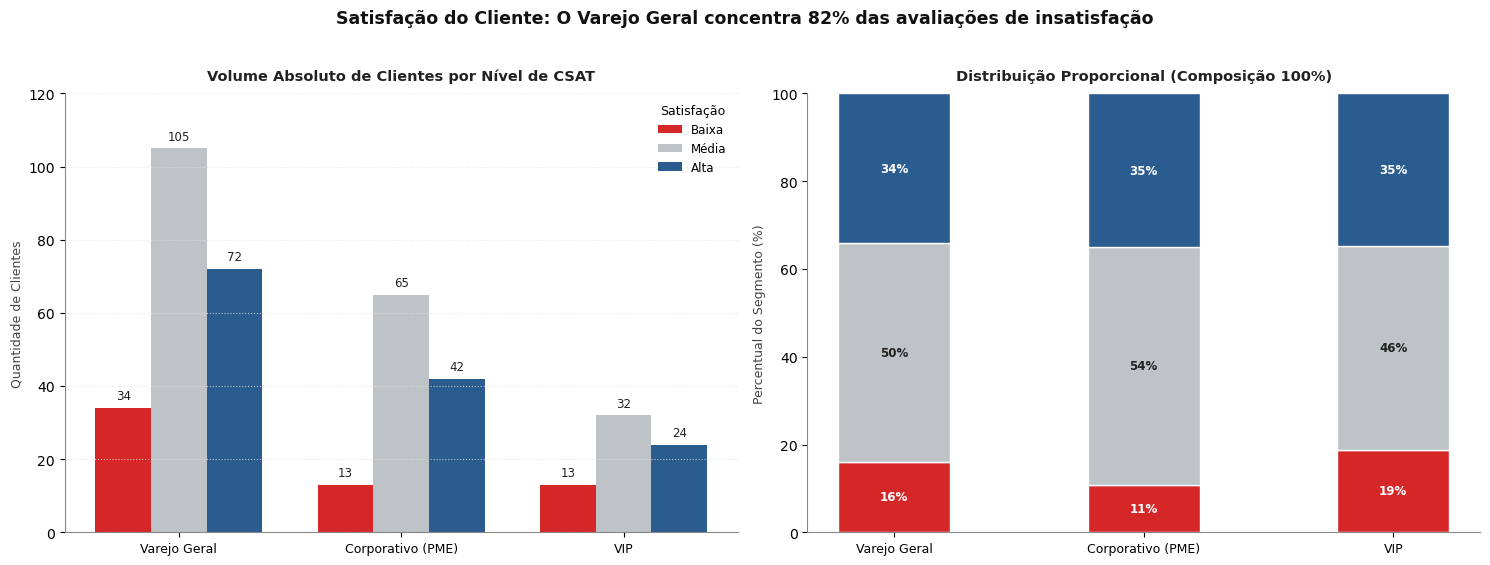

In [4]:
# 1. Preparação das tabelas de dados
ordem_csat = ["Baixa", "Média", "Alta"]
ordem_seg = ["Varejo Geral", "Corporativo (PME)", "VIP"]

# Contagem simples
tab_barras_abs = pd.crosstab(
    df_varejo["segmento_cliente"], df_varejo["satisfacao_csat"]
).reindex(index=ordem_seg, columns=ordem_csat)

# Composição 100%
tab_barras_prop = (
    tab_barras_abs.div(tab_barras_abs.sum(axis=1), axis=0) * 100
)

# Cores semânticas focadas no objetivo gerencial
# Vermelho-alerta para Baixa, cinzas para intermediário e azul corporativo para Alta
paleta_cores = {
    "Baixa": "#d62728",
    "Média": "#bdc3c7",
    "Alta": "#2b5c8f",
}

# 2. Construção da Visualização Integrada (2 Painéis)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=100)

posicoes = np.arange(len(ordem_seg))
largura = 0.25

# -------------------------------------------------------------------------
# PAINEL 1: BARRAS LADO A LADO (Volume Absoluto)
# -------------------------------------------------------------------------
for i, nivel in enumerate(ordem_csat):
    offset = (i - 1) * largura
    valores = tab_barras_abs[nivel]
    retângulos = ax1.bar(
        posicoes + offset,
        valores,
        width=largura,
        label=nivel,
        color=paleta_cores[nivel],
        edgecolor="none",
    )
    # Rótulo de dados direto sobre as barras (elimina necessidade de consultar o eixo Y repetidamente)
    for barra in retângulos:
        altura = barra.get_height()
        ax1.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 1.5,
            f"{int(altura)}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            color="#222222",
        )

ax1.set_title(
    "Volume Absoluto de Clientes por Nível de CSAT",
    fontsize=10.5,
    fontweight="bold",
    pad=10,
    color="#222222",
)
ax1.set_xticks(posicoes)
ax1.set_xticklabels(ordem_seg, fontsize=9)
ax1.set_ylabel("Quantidade de Clientes", fontsize=9, color="#444444")
ax1.set_ylim(0, max(tab_barras_abs.max()) + 15)
ax1.grid(axis="y", linestyle=":", color="#e0e0e0", alpha=0.8)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#888888")
ax1.spines["bottom"].set_color("#888888")
ax1.legend(
    title="Satisfação",
    frameon=False,
    loc="upper right",
    fontsize=8.5,
    title_fontsize=9,
)

# -------------------------------------------------------------------------
# PAINEL 2: BARRAS EMPILHADAS 100% (Composição Percentual)
# -------------------------------------------------------------------------
acumulador = np.zeros(len(ordem_seg))

for nivel in ordem_csat:
    valores_perc = tab_barras_prop[nivel]
    barras_emp = ax2.bar(
        posicoes,
        valores_perc,
        bottom=acumulador,
        label=nivel,
        width=0.45,
        color=paleta_cores[nivel],
        edgecolor="#ffffff",
        linewidth=1,
    )

    # Rótulos no centro dos blocos empilhados
    for j, barra in enumerate(barras_emp):
        altura_bloco = barra.get_height()
        if altura_bloco >= 7:  # Apenas exibe rótulo se houver espaço legível
            pos_y = acumulador[j] + (altura_bloco / 2)
            ax2.text(
                barra.get_x() + barra.get_width() / 2,
                pos_y,
                f"{altura_bloco:.0f}%",
                ha="center",
                va="center",
                fontsize=8.5,
                color="#ffffff" if nivel in ["Baixa", "Alta"] else "#222222",
                fontweight="bold",
            )
    acumulador += valores_perc

ax2.set_title(
    "Distribuição Proporcional (Composição 100%)",
    fontsize=10.5,
    fontweight="bold",
    pad=10,
    color="#222222",
)
ax2.set_xticks(posicoes)
ax2.set_xticklabels(ordem_seg, fontsize=9)
ax2.set_ylabel("Percentual do Segmento (%)", fontsize=9, color="#444444")
ax2.set_ylim(0, 100)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#888888")
ax2.spines["bottom"].set_color("#888888")

# Título global executivo para a figura dupla
plt.suptitle(
    "Satisfação do Cliente: O Varejo Geral concentra 82% das avaliações de insatisfação",
    fontsize=12.5,
    fontweight="bold",
    color="#111111",
    y=1.02,
)

plt.tight_layout()
plt.show()

## <span style="color:blue"> 5) Exercício Selecionado </span>

O exercício a seguir foi selecionado do Capítulo 2 de Anderson et al. (2021). Para fazer todos eles, você precisará das bases de dados do livro. Para isso, você pode criar uma conta de aluno no site da editora e acesse os materiais didáticos disponíveis para esse livro. Ou usar os links disponibilizados neste Jupyter.

### **<span style="color:green">Exercício 1 (Adaptado do Estudo de Caso 2 do Livro)</span>**

A indústria cinematrográfica é um setor competitivo. Mais de 50 estúdios produzem um total de 300 a 400 novos filmes por ano, e o sucesso finenceiro de cada filme varia consideravelmente. As vendas brutas do fim de semana de estria (em milhões de US$), o número de salas de cinema em que o filme foi exibido e o número de semanas durante as quais o filme esteve em lançamento são variáveis comuns utilizadas para medir o sucesso de um filme. Os dados coletados para uma amostra de 100 filmes produzidos em 2011 no link abaixo:

Conjunto de dados: https://github.com/humbertoeliaslopes/AD_negocios/blob/09c51016706f6a932880621f9f519aa9ce1caf97/2011Movies.xlsx

Utilizando este conjunto de dados faça o seguinte, usando as técnicas de storytelling de dados:

1) crie resumos tabulares e gráficos para cada uma das quatro variáveis;
2) crie um diagrama de dispersão para explorar a relação entre as vendas brutas totais e as vendas brutas no fim de semana de estreia;
3) crie outro diagrama de dispersão para explorar a relação entre as vendas brutas totais e o número de salas de cinema;
4) crie mais um diagrama de dispersão, desta vez, explorando a relação entre as vendas brutas totais e o número de semanas em lançamento.
5) Depois de sintetizar o comportamento dos dados por meio de tabelas e gráficos, escreva um relatório de análise, de dois parágrafos, que seja consistente com as informações apresentadas.

## <span style="color:blue"> 6) Resolução do Exercício Selecionado </span>

Esta parte será atualizada posteriormente, já que o Exercício 1 valerá ponto!